## Validation Test

**Important Note**: The test assumes your function have the following parameters available

```
# Default

your_func(signal, Np, conjugate)

# if fam = True (need hop size argument L)

your_func(signal, Np, L, conjugate)

```

where signal is the input signal argument, Np is the size of the first windowing function (or the size of your channelizer), conjugate (bool) for whether to calculate Non Conjugate SCD or Conjugate SCD. And your function must output frequency and alpha mapping **with the same size as your spectral correlation value**.

Example: 
- Sx (spectral correlation values): N x Np
- f  (frequency mapping) : N x Np
- alpha (alpha mapping)  : N x Np


**Note**:

- The default Np size is 512 to show good convergence to theoretical value. The higher the Np, the better the convergence but also higher memory usage and test time. (You also have to change the starting signal length in the test function if you are raising Np higher than 512)
- The test is going to use a lot of RAM. 32GB is minimum for 2^19 signal length. Decrease default max_log_2 value otherwise.

*Input*:
- func_lambda: Your SCD Estimation Function
- name (String): Your Algorithm name. Default: "algorithm"
- Np (int): Size of your channelizer. Default: 512
- snr (int): Signal-to-Noise Ratio in db. Default: 10
- max_log_2 (int): Maximum power of 2 signal length you want to test. Default: 20
- no_of_run (int): Number of time to repeat the test and pool the result. Default: 1
- alpha_max (float): The maximum alpha frequency to validate up to. Default: 1.0
- conjugate (bool): Whether to validate non-conjugate SCD or conjugate SCD. Default: False
- plot (bool): Whether to show plots. Default: True
- save (bool): Whether to save the figures in \fig. Default: True
- fam (bool): Whether we are testing fam which requires argument L. Default: False

*Output*:
- scd_rmse (array): root mean square error at each signal length tested
- signal_length (array): signal length used

In [1]:
from scf_test.algorithm import fam, fast_sc_wrapper
import scf_test.tests as test

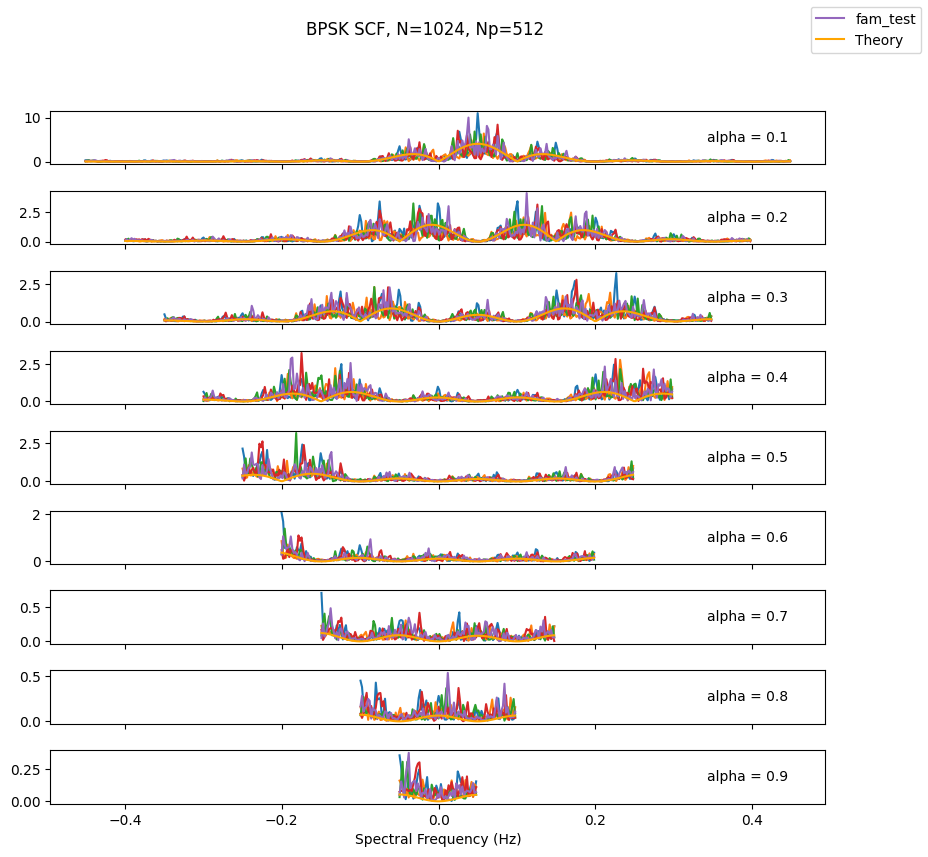

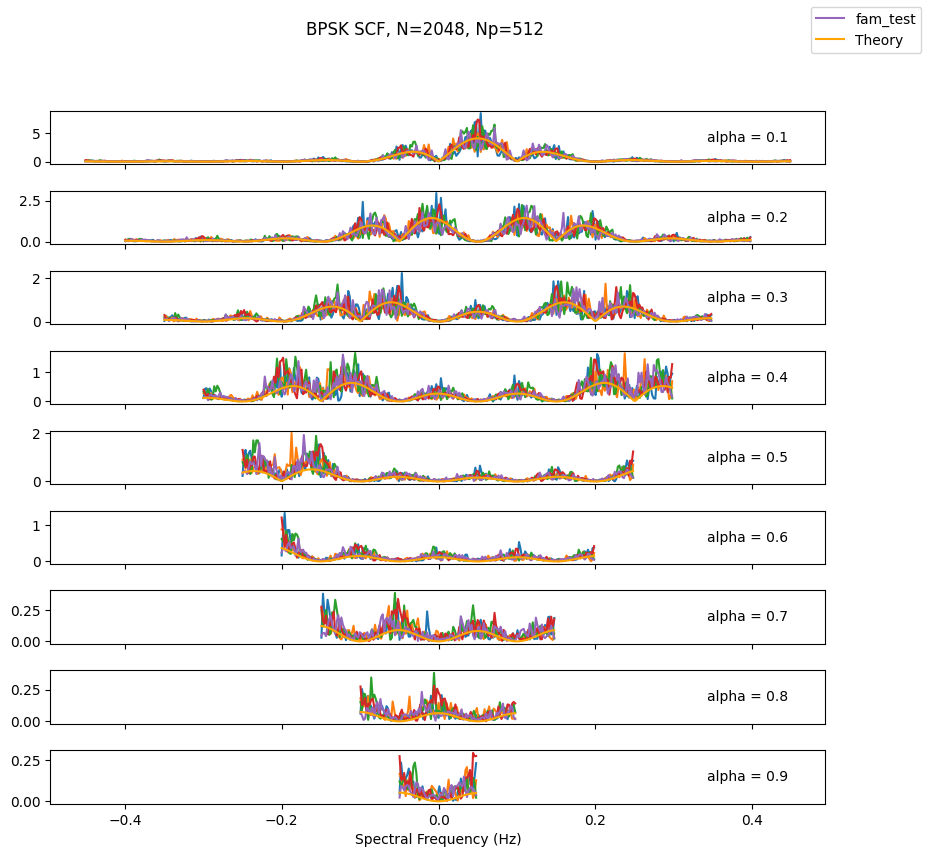

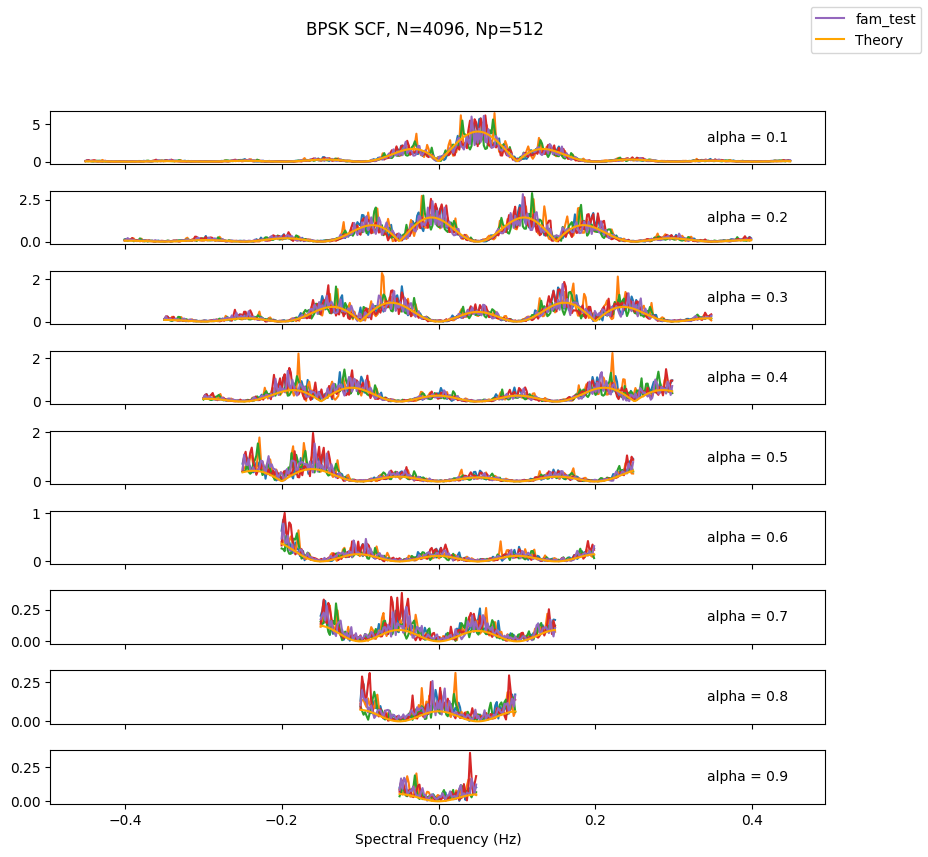

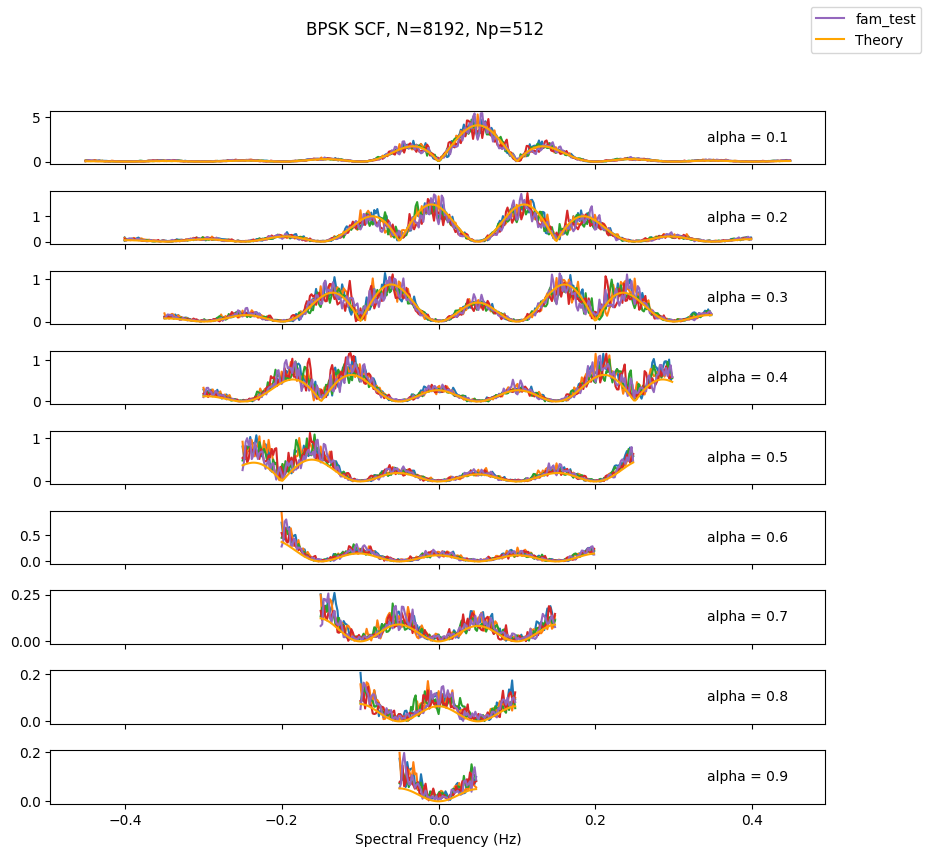

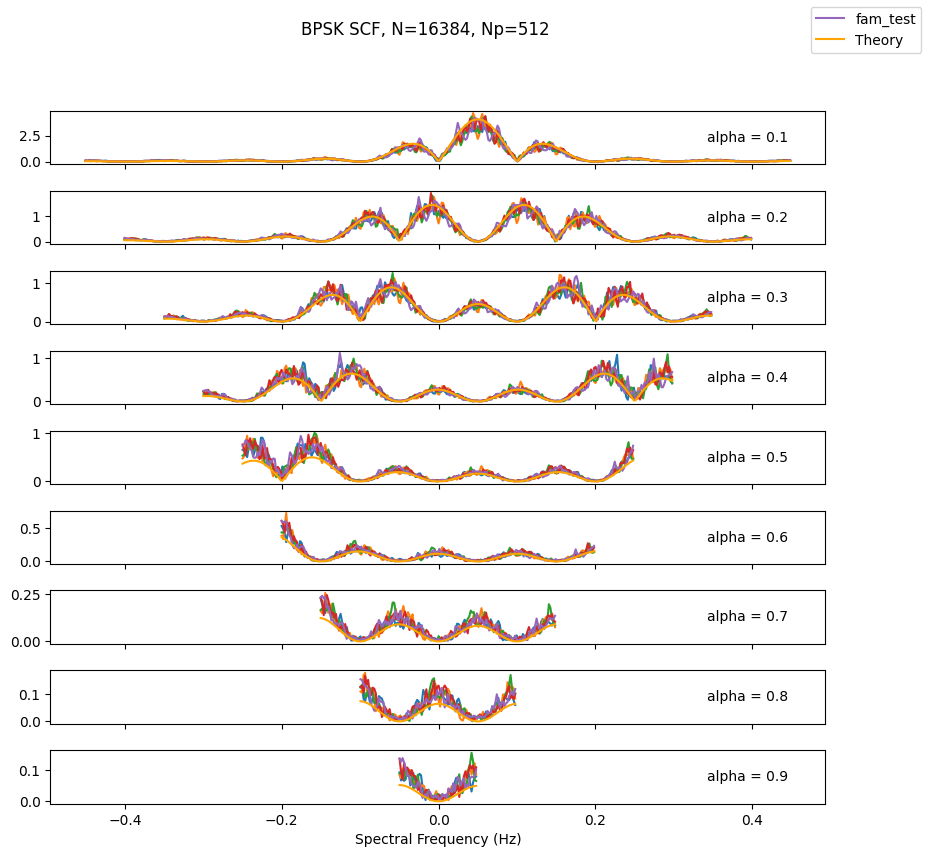

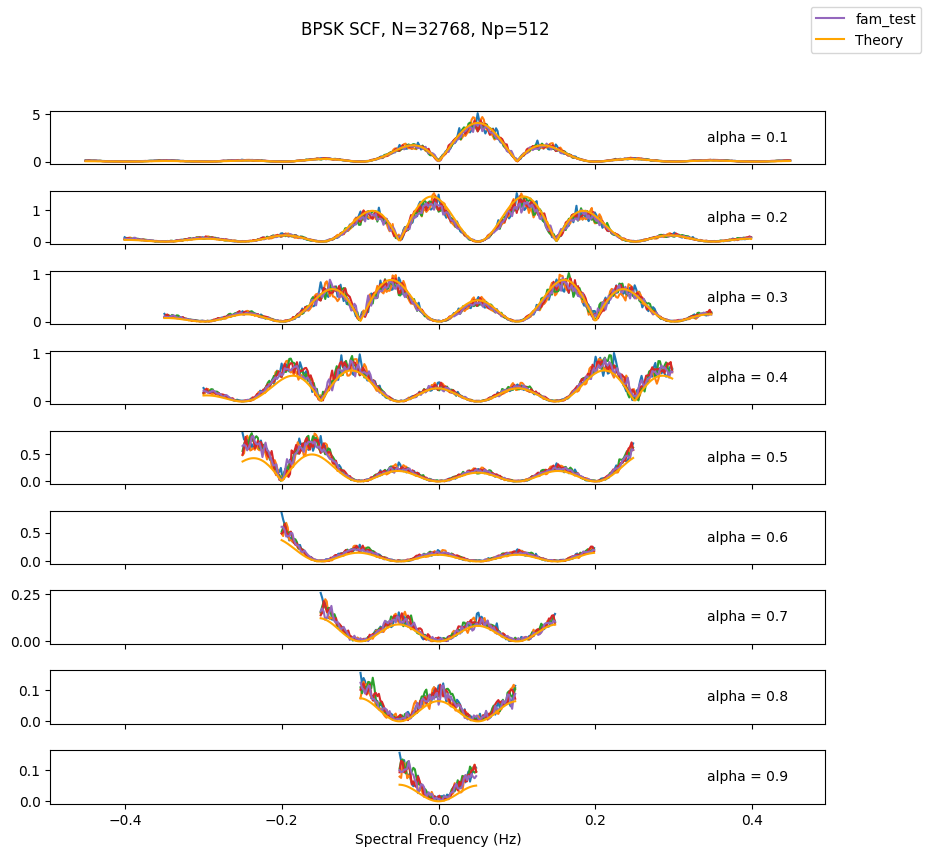

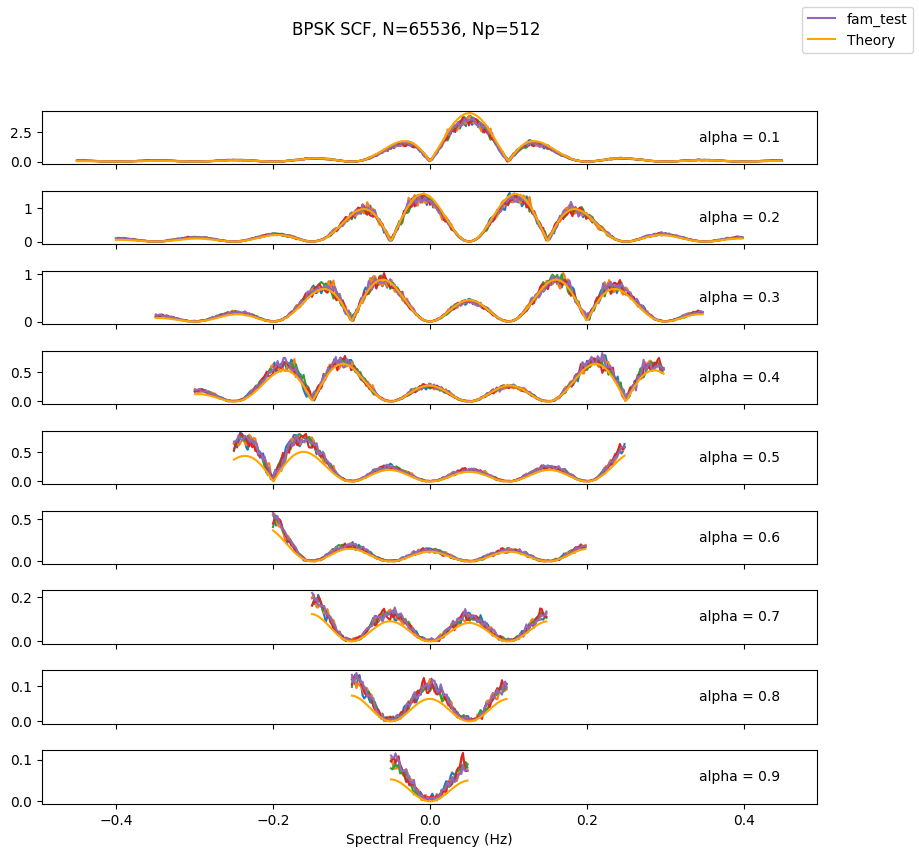

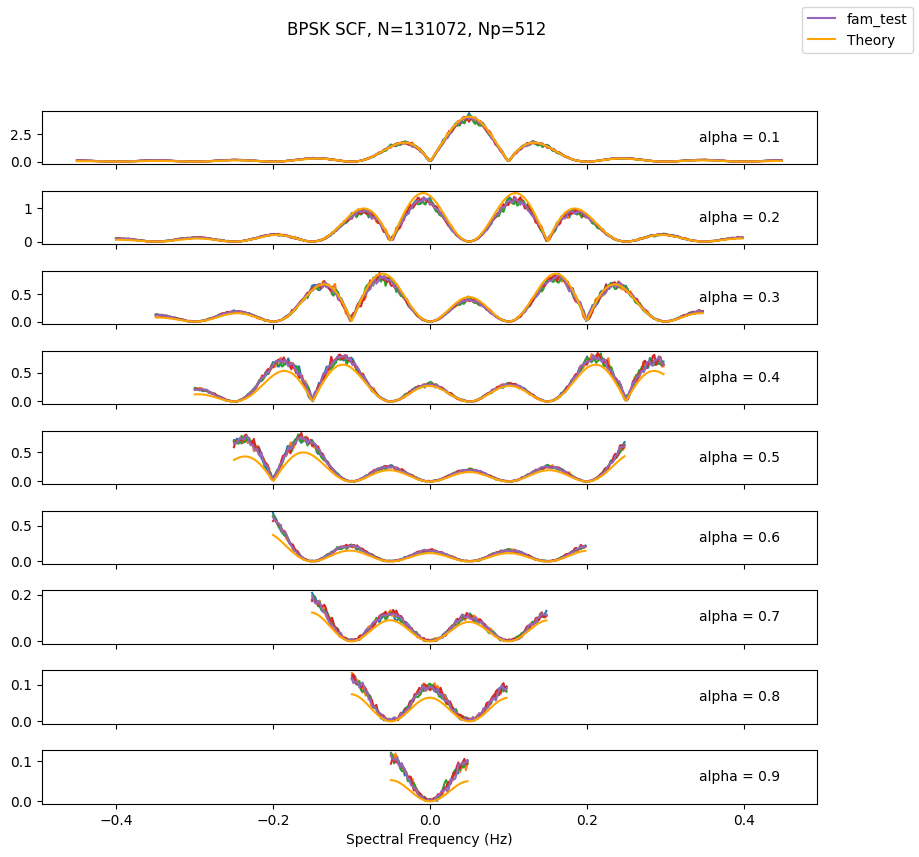

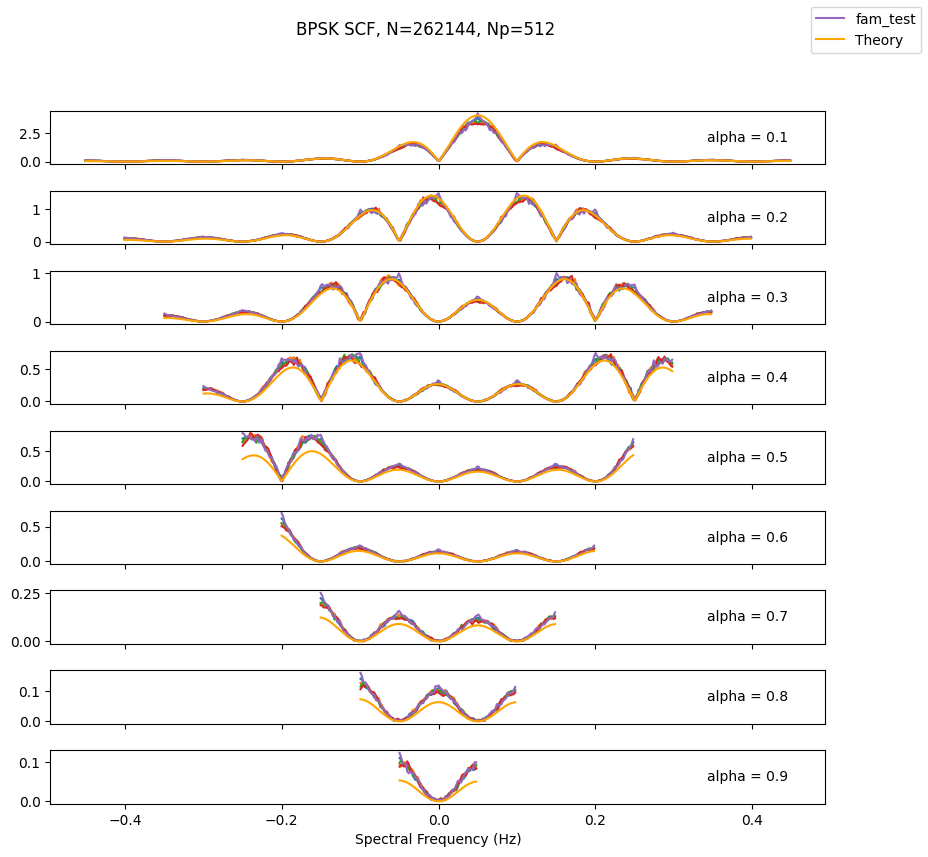

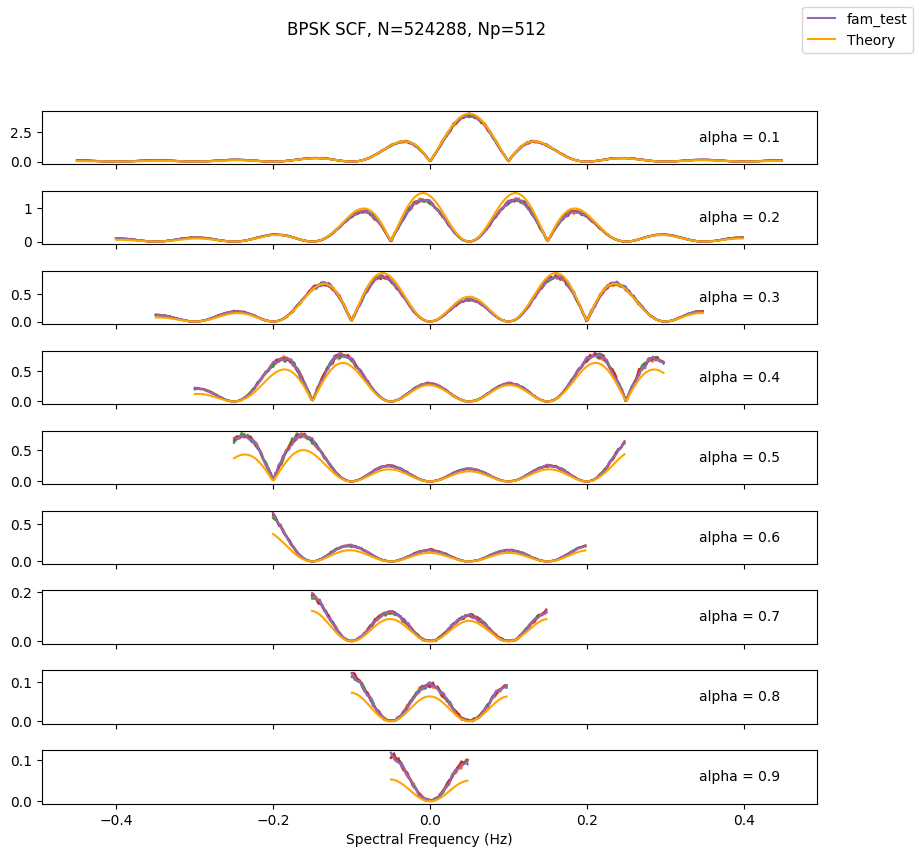

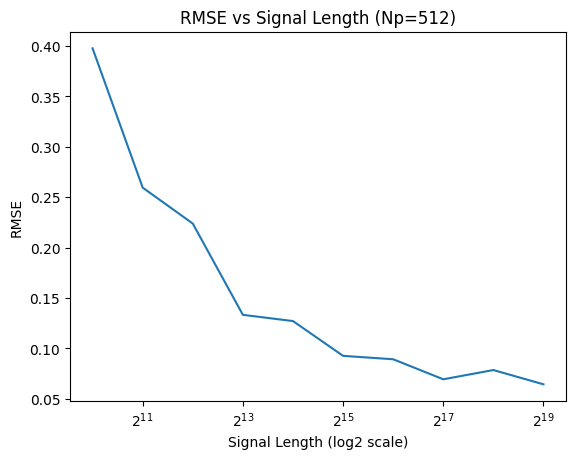

In [ ]:
fam_rmse, signal_length = test.validation_test(fam, name="fam_test", no_of_run=5, fam=True)

**Extra Note**: The test might fail to extract the slice due to alpha resolution being bigger than what is assumed (delta_alpha = 1/N), but since RMSE is calculated only on what is extracted, the validation should be fine. 

Here we will use Fast SC as an example of this. Also, notice how Fast SC is missing the shift of the 0.05 Hz Carrier Frequency Offset (CFO). Also it cuts off way too early.

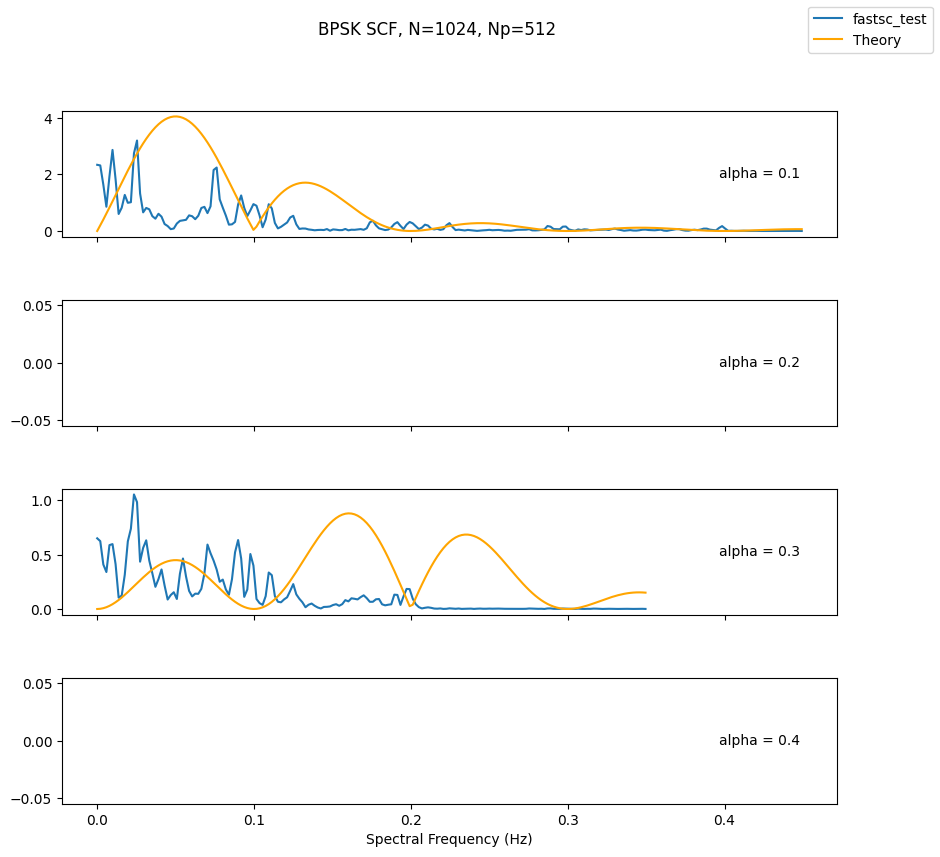

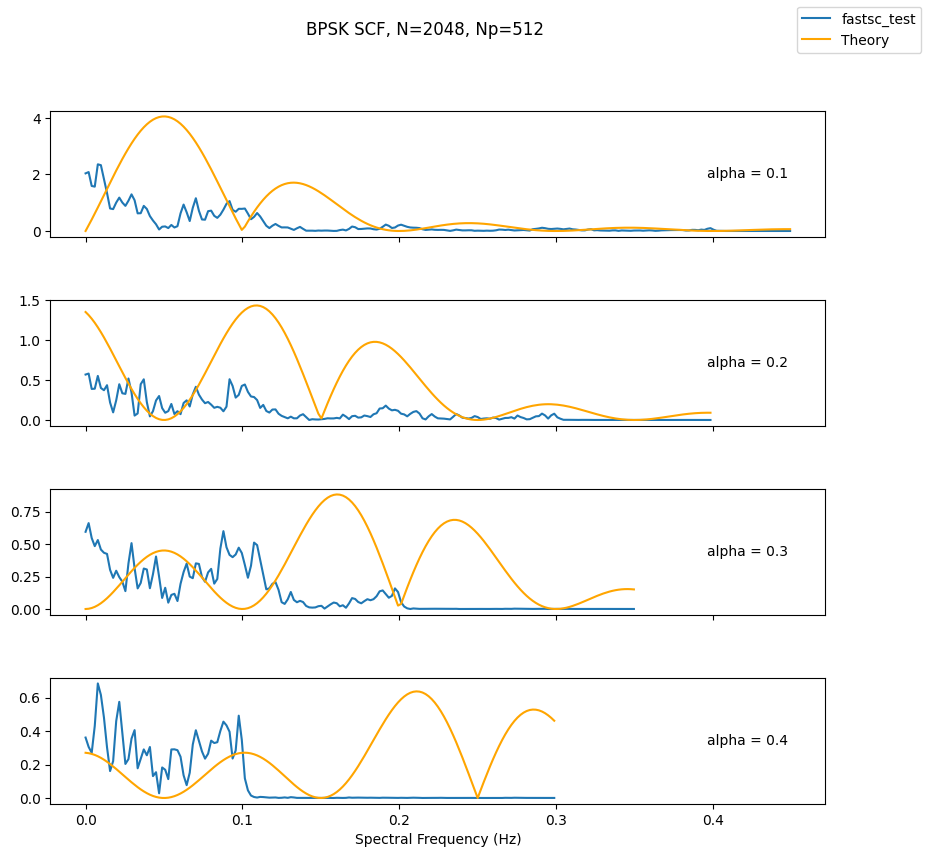

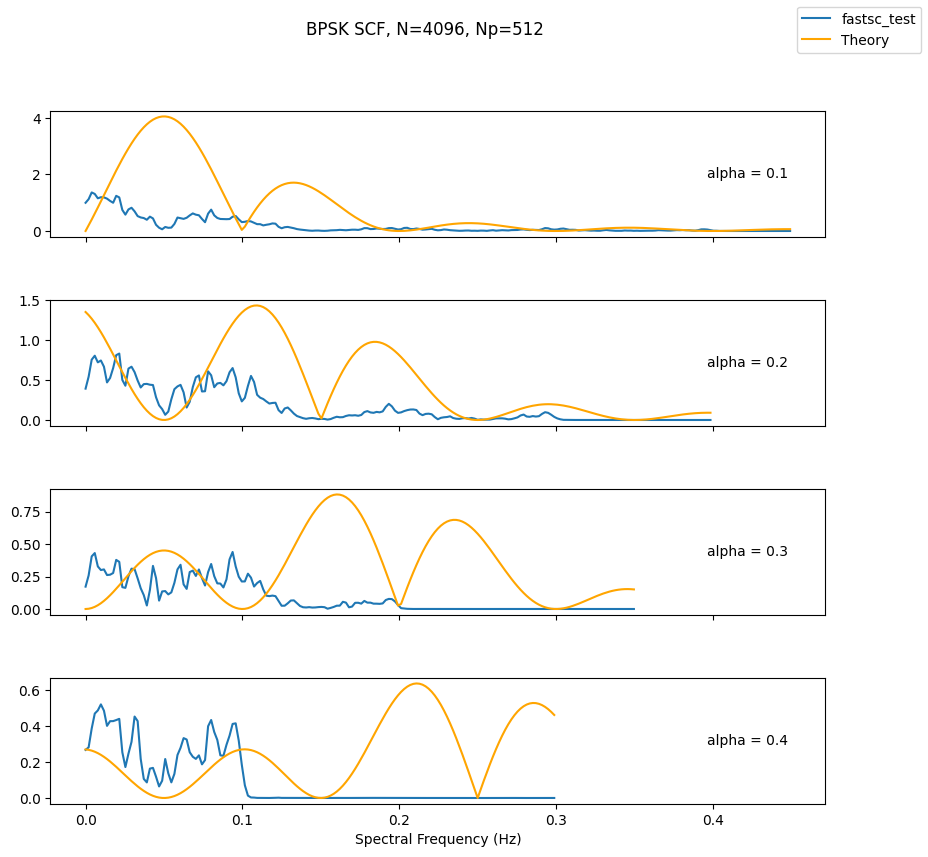

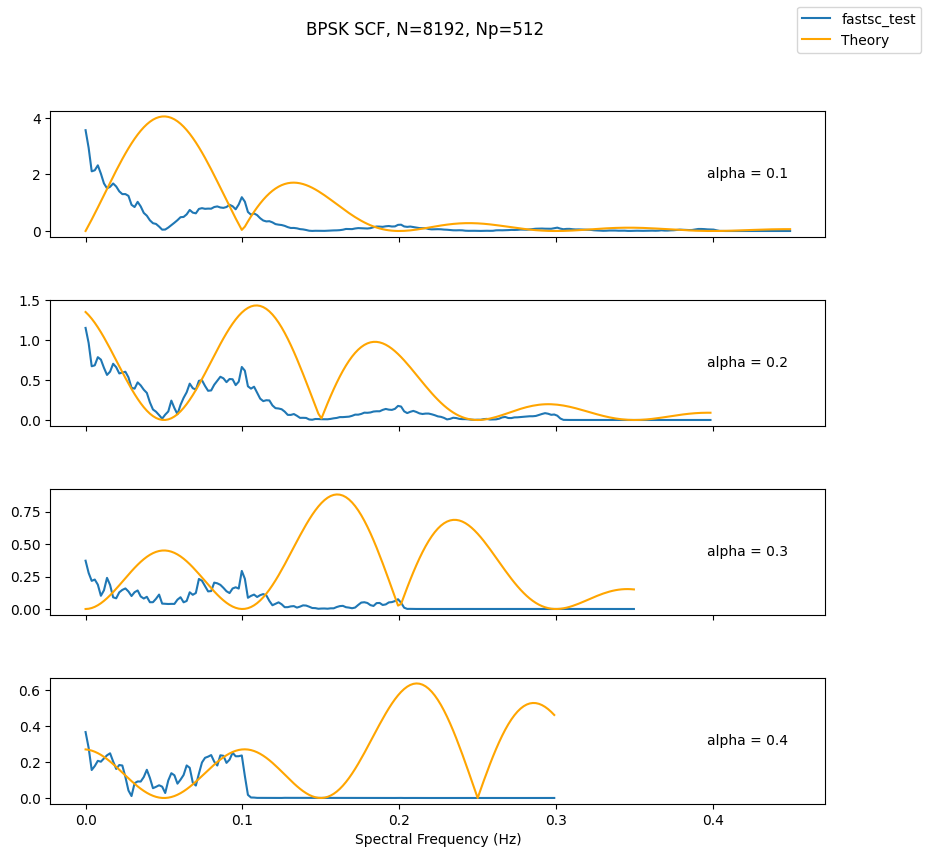

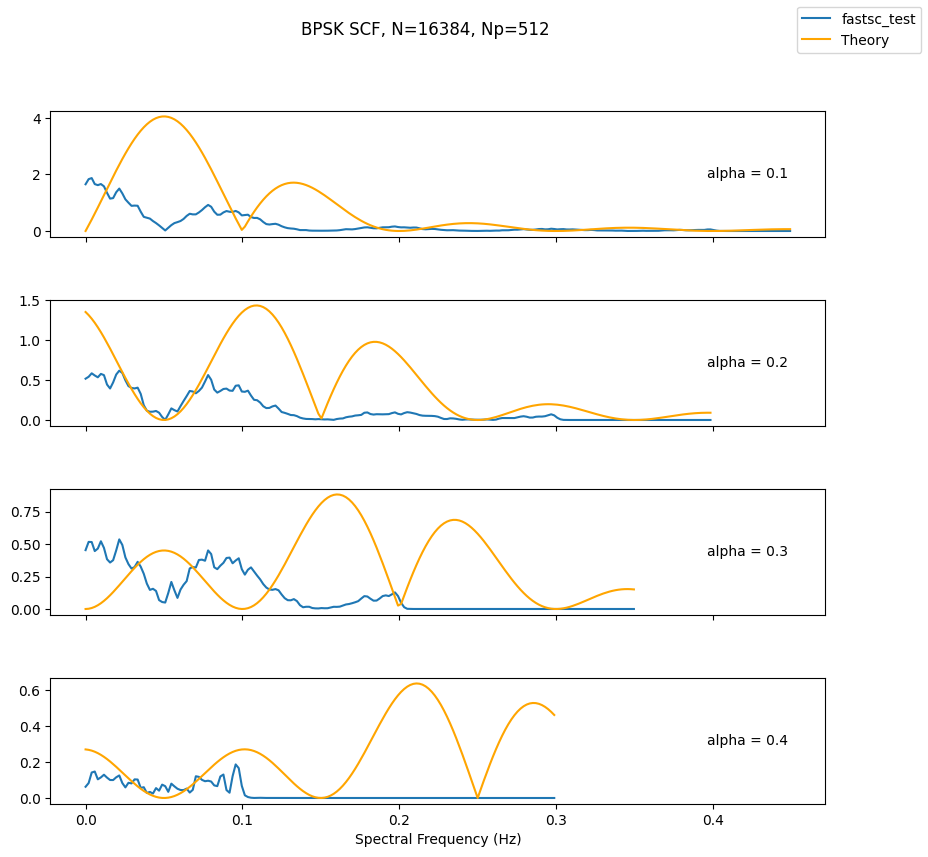

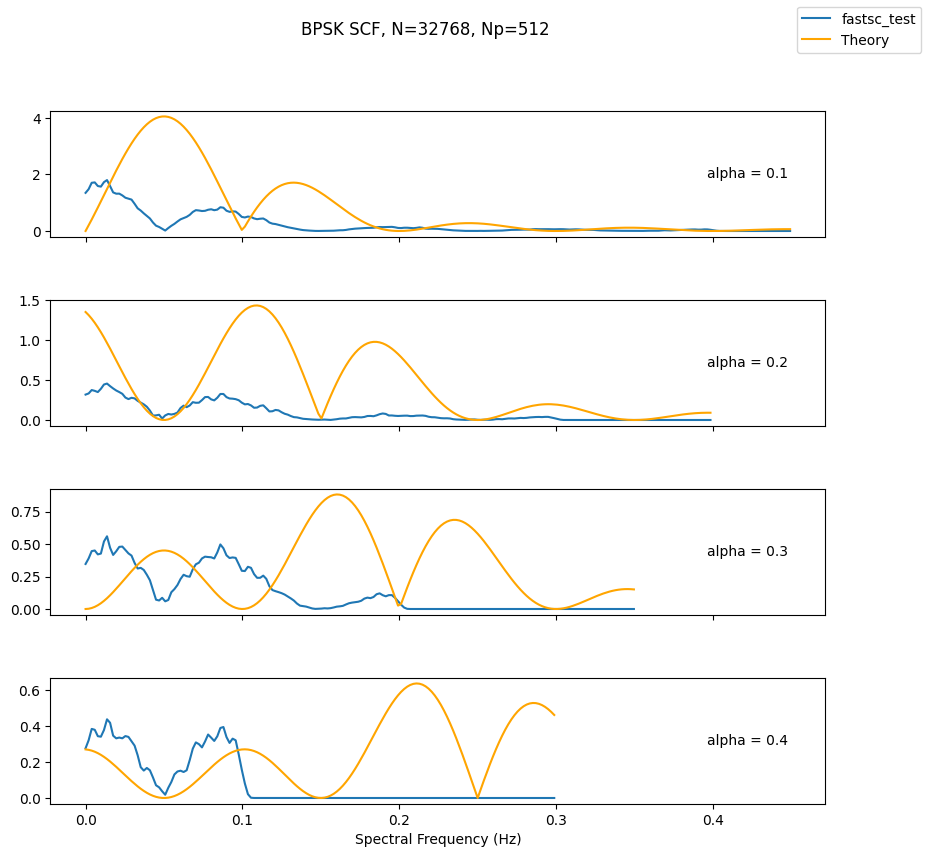

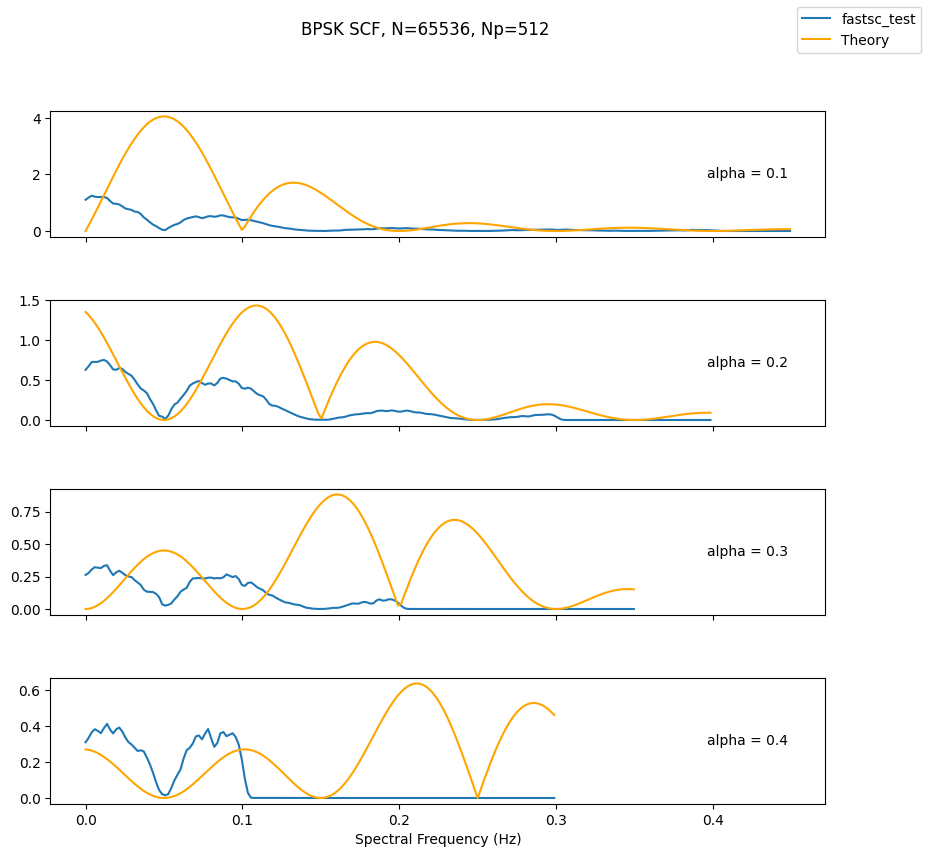

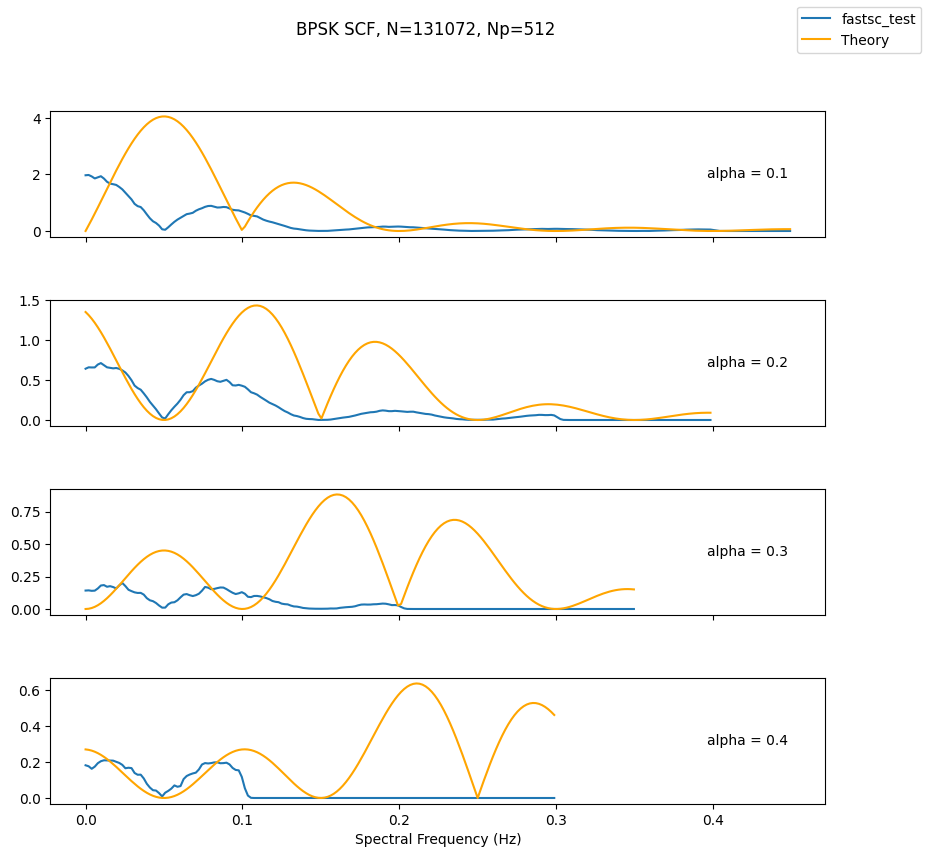

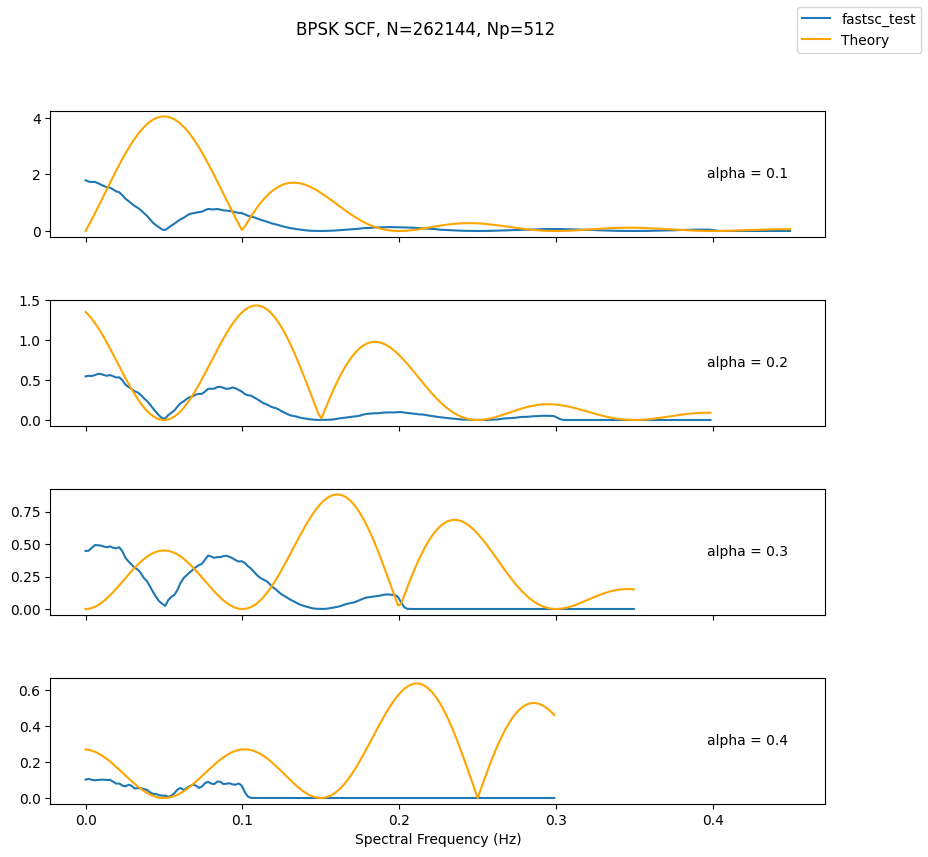

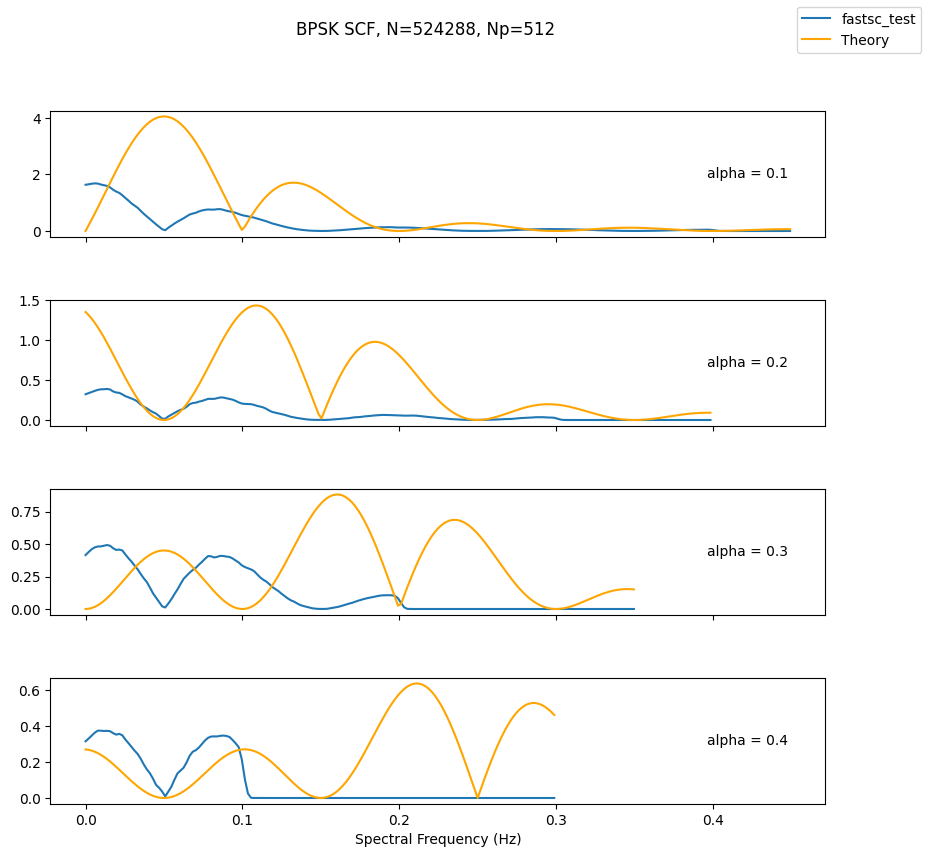

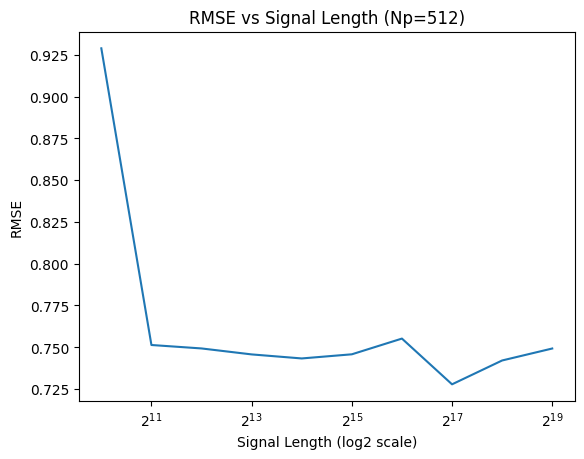

In [6]:
fast_sc_rmse, signal_length = test.validation_test(fast_sc_wrapper, name="fastsc_test", alpha_max=0.5) # Only 1 run so it is quick

**Extra**: Conjugate Validation

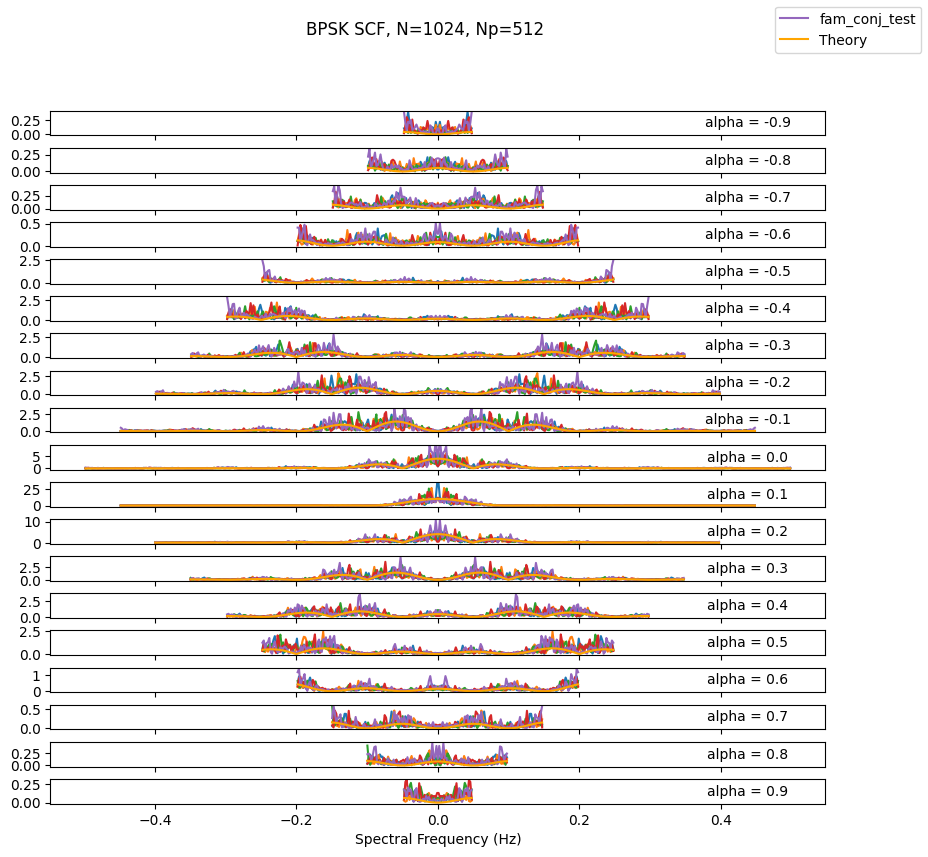

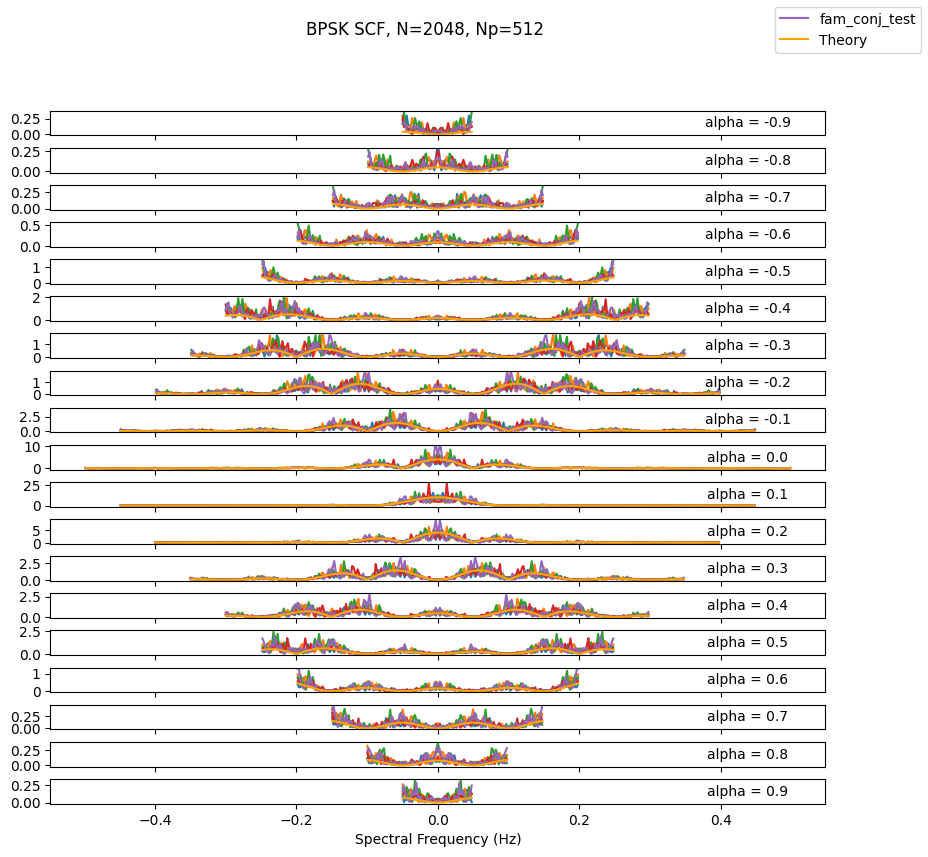

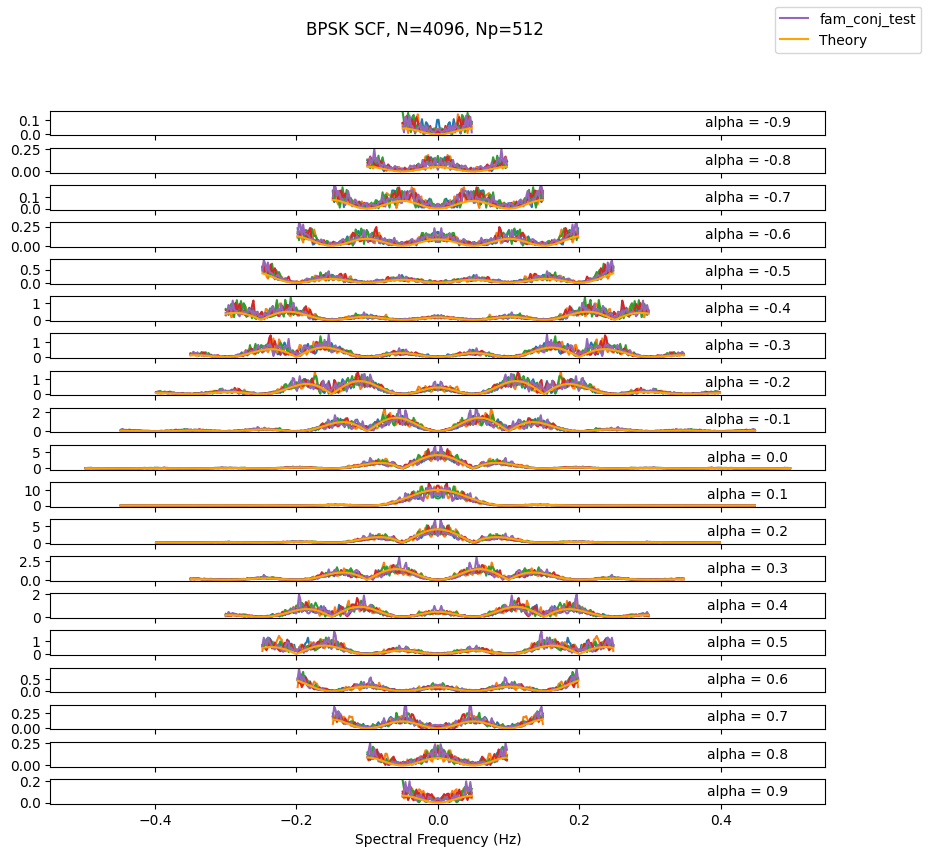

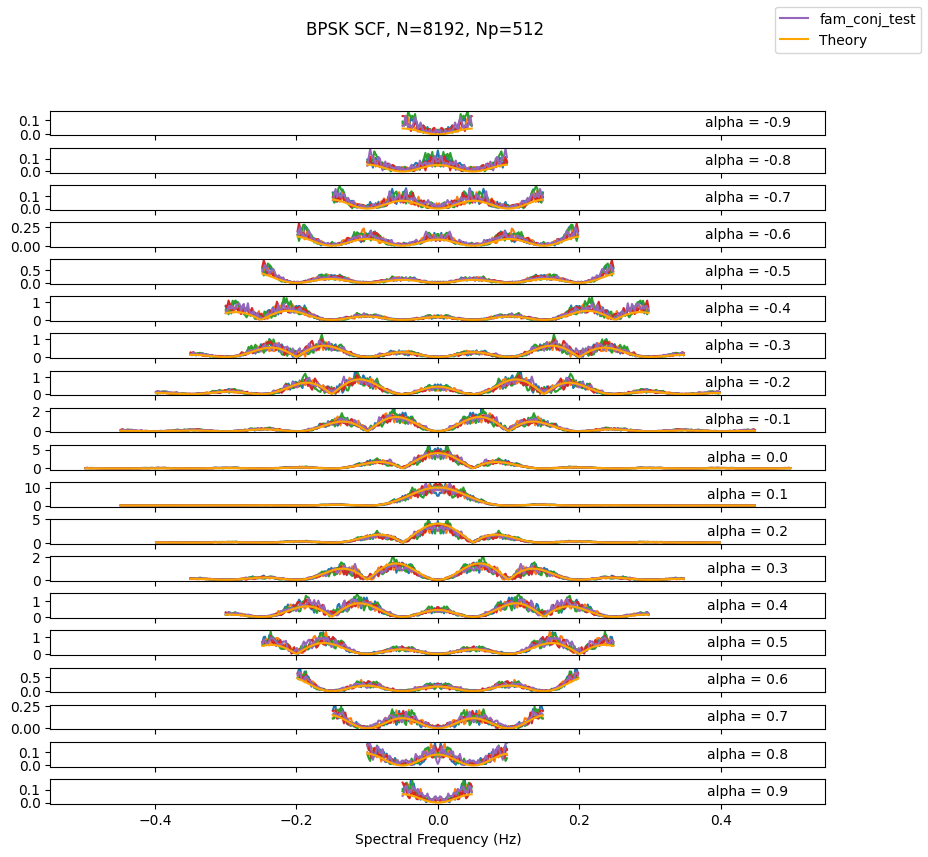

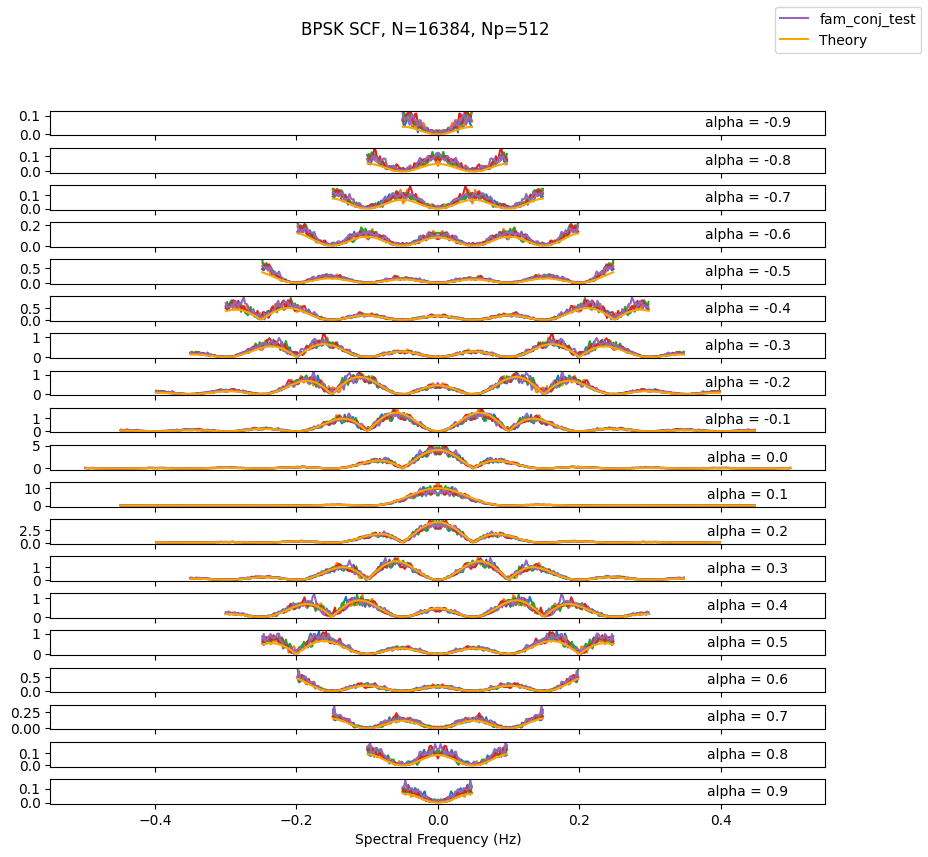

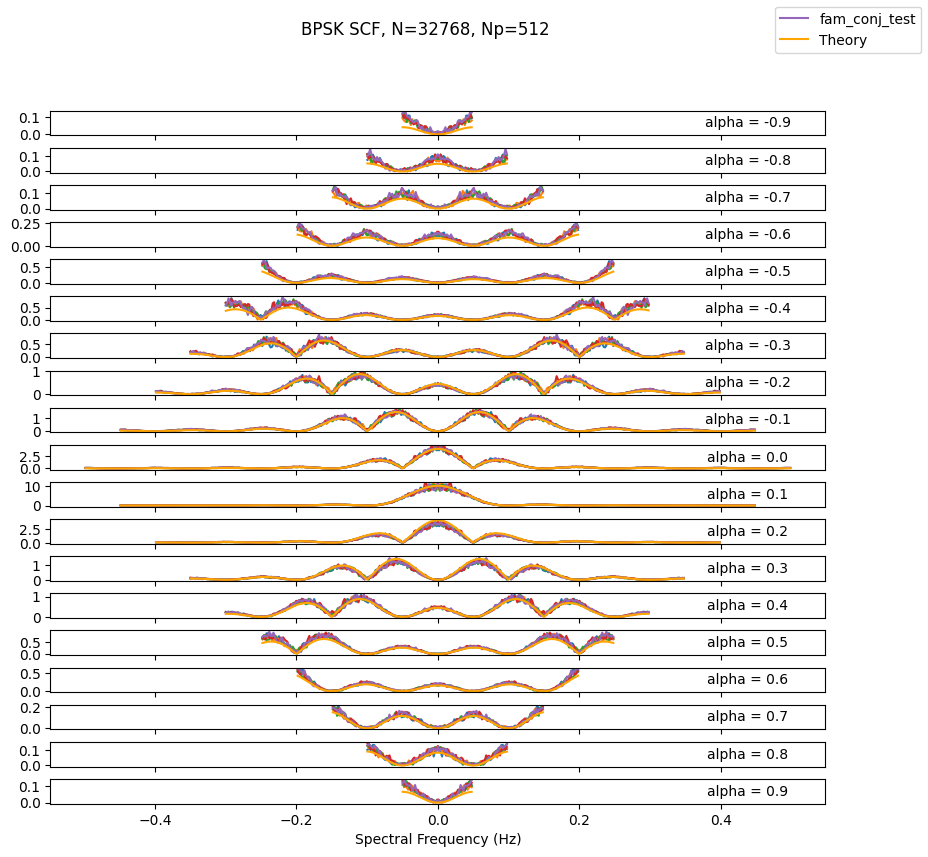

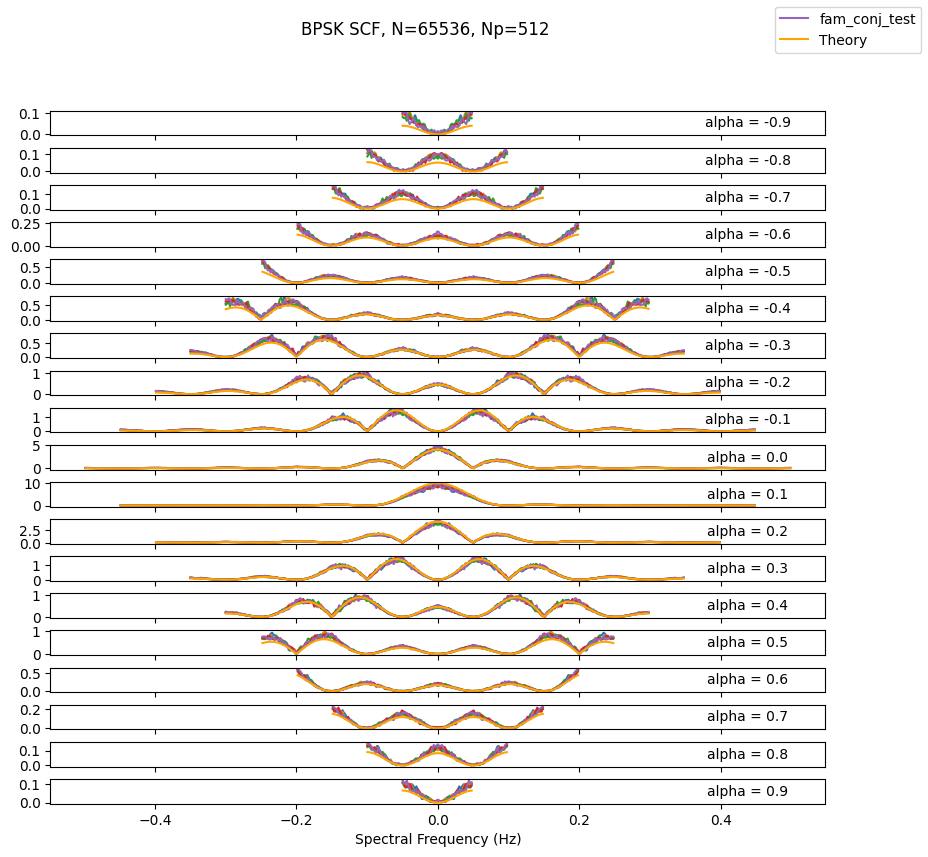

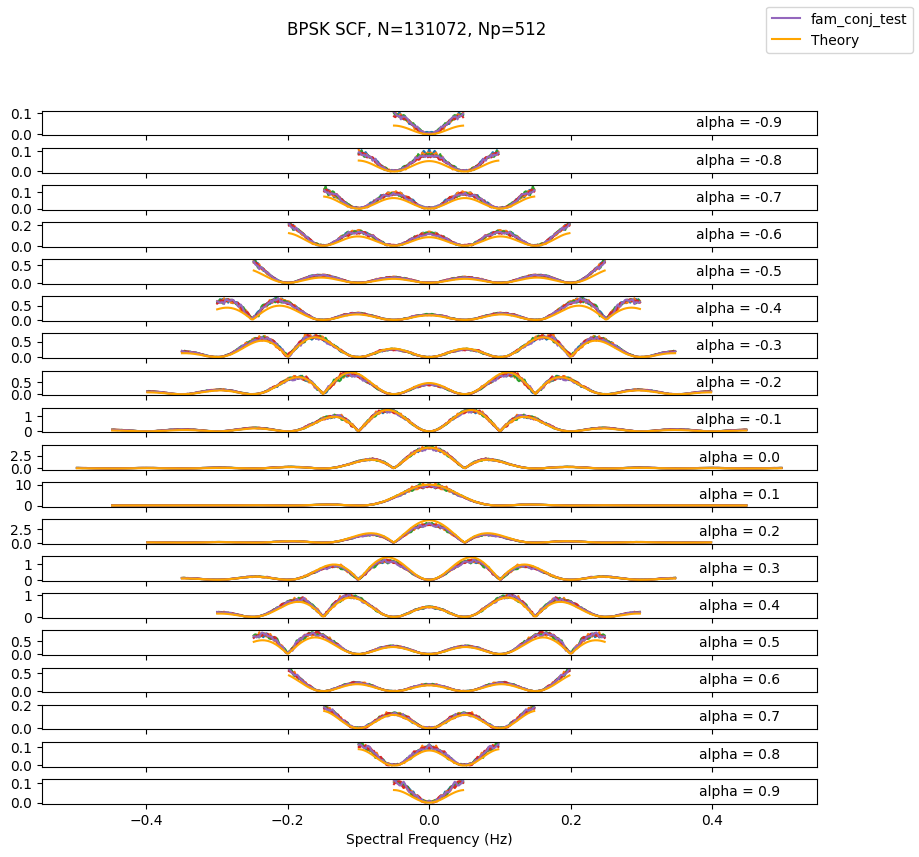

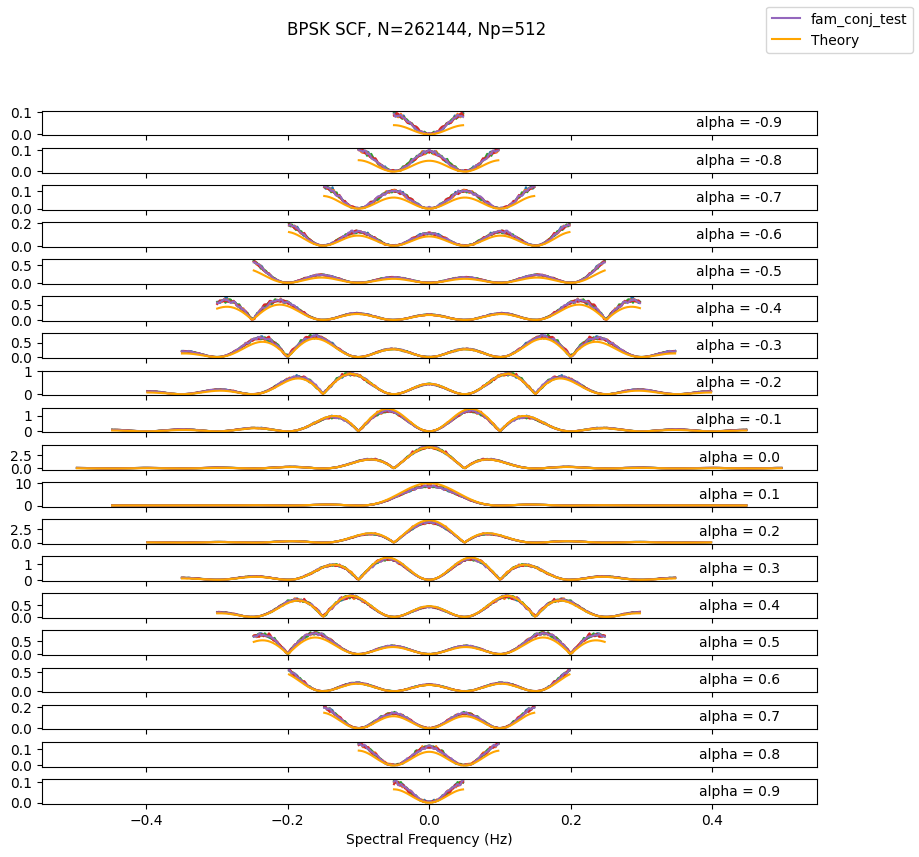

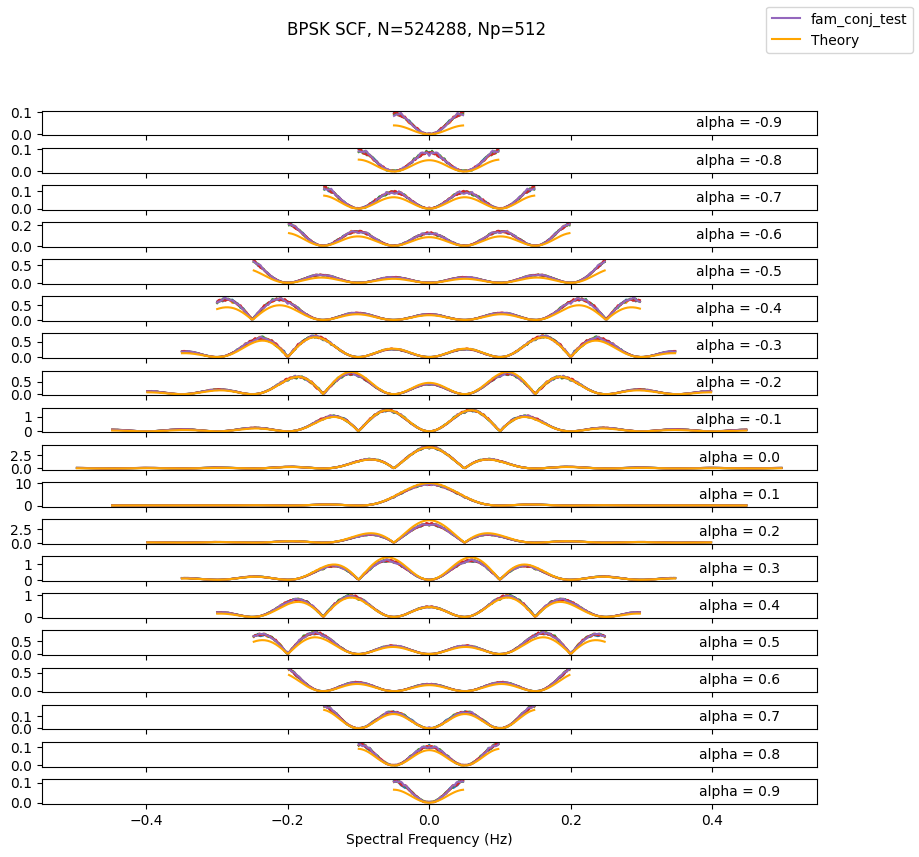

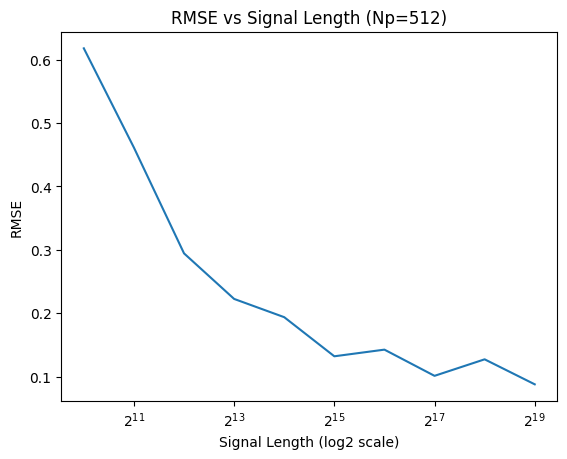

In [4]:
fam_conj_rmse, signal_length = test.validation_test(fam, name="fam_conj_test", no_of_run=5, conjugate=True, fam=True)

## 2. Extended Validation Test

If you want to see what is the optimal N and Np given an SNR, we also have a function for that. It just runs the validation test with different N, Np arguments and plot it.

SNR = 0, Np = 8
SNR = 0, Np = 16
SNR = 0, Np = 32
SNR = 0, Np = 64
SNR = 0, Np = 128
SNR = 0, Np = 256
SNR = 0, Np = 512
SNR = 1, Np = 8
SNR = 1, Np = 16
SNR = 1, Np = 32
SNR = 1, Np = 64
SNR = 1, Np = 128
SNR = 1, Np = 256
SNR = 1, Np = 512
SNR = 2, Np = 8
SNR = 2, Np = 16
SNR = 2, Np = 32
SNR = 2, Np = 64
SNR = 2, Np = 128
SNR = 2, Np = 256
SNR = 2, Np = 512
SNR = 3, Np = 8
SNR = 3, Np = 16
SNR = 3, Np = 32
SNR = 3, Np = 64
SNR = 3, Np = 128
SNR = 3, Np = 256
SNR = 3, Np = 512
SNR = 4, Np = 8
SNR = 4, Np = 16
SNR = 4, Np = 32
SNR = 4, Np = 64
SNR = 4, Np = 128
SNR = 4, Np = 256
SNR = 4, Np = 512
SNR = 5, Np = 8
SNR = 5, Np = 16
SNR = 5, Np = 32
SNR = 5, Np = 64
SNR = 5, Np = 128
SNR = 5, Np = 256
SNR = 5, Np = 512
SNR = 6, Np = 8
SNR = 6, Np = 16
SNR = 6, Np = 32
SNR = 6, Np = 64
SNR = 6, Np = 128
SNR = 6, Np = 256
SNR = 6, Np = 512
SNR = 7, Np = 8
SNR = 7, Np = 16
SNR = 7, Np = 32
SNR = 7, Np = 64
SNR = 7, Np = 128
SNR = 7, Np = 256
SNR = 7, Np = 512
SNR = 8, Np = 8
SNR = 8, Np = 16

MovieWriter Pillow unavailable; using Pillow instead.


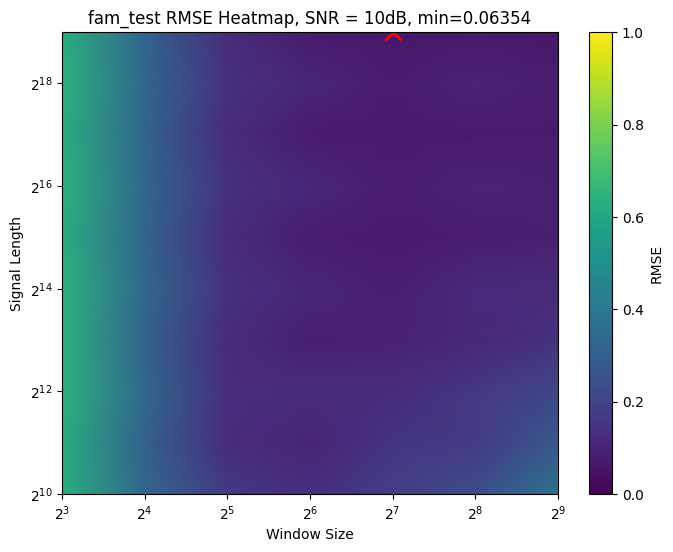

In [1]:
from scf_test.tests import extended_validation_test
from scf_test.algorithm import fam

fam_rmse_mat, signal_length_mat = extended_validation_test(fam, name="fam_test", no_of_run=5, fam=True)